# Lab 6. 

## Neighborhood methods for RecSys.

In this lab you will implmented two neighborhood approacher to recommend movies to users. Specifically, you will implement user-based and item-based collaborative filtering methods.

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import seaborn as sns

Import the data in 'U.csv'

In [104]:
df = pd.read_csv('U.csv', header=None)
R = df.values.astype(float)
R

array([[5., 3., 4., ..., 0., 0., 0.],
       [4., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [5., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 5., 0., ..., 0., 0., 0.]], shape=(943, 1682))

Split your dataset:

In [105]:
def count_diffZero(row):
    cont = 0
    for i in row:
        if i != 0:
            cont += 1
    return cont

Original_row = [0, 3, 0, 5, 2, 0, 0, 0]

Let's say val = position 1 (3), test = position 4 (2), train = position 3 (5)

Train_row = [0, 0, 0, 5, 0, 0, 0, 0]

Val_row = [0, 3, 0, 0, 0, 0, 0, 0]

Test_row = [0, 0, 0, 0, 2, 0, 0, 0]

Reconstructed_row = train_row + val_row + test_row

[0, 3, 0, 5, 2, 0, 0, 0] == original_row

In [106]:
matrix_train = []
matrix_valid = []
matrix_test = []

percent_val = 0.25
percent_test = 0.25
percent_train = 1 - percent_val - percent_test

n_users, n_items = R.shape

for i in range(n_users):
    row = R[i]
    
    rated_indices = np.where(row != 0)[0]

    if len(rated_indices) < 3:
        matrix_train.append(np.zeros(n_items))
        matrix_valid.append(np.zeros(n_items))
        matrix_test.append(np.zeros(n_items))
        continue

    train_val_idx, test_idx = train_test_split(rated_indices, test_size=percent_test, random_state=42)
    train_idx, valid_idx = train_test_split(train_val_idx, test_size=percent_val / (percent_train + percent_val), random_state=42)

    train_row = np.zeros(n_items)
    valid_row = np.zeros(n_items)
    test_row = np.zeros(n_items)

    train_row[train_idx] = row[train_idx]
    valid_row[valid_idx] = row[valid_idx]
    test_row[test_idx] = row[test_idx]

    matrix_train.append(train_row)
    matrix_valid.append(valid_row)
    matrix_test.append(test_row)

R_train = np.array(matrix_train)
R_valid = np.array(matrix_valid)
R_test = np.array(matrix_test)

print("Train matrix shape:", R_train.shape)
print("Validation matrix shape:", R_valid.shape)
print("Test matrix shape:", R_test.shape)

print("Original first row:", R[0])
print("Train first row:   ", R_train[0])
print("Valid first row:   ", R_valid[0])
print("Test first row:    ", R_test[0])

reconstructed_row = R_train[0] + R_valid[0] + R_test[0]
print("Reconstructed row: ", reconstructed_row)
print("Equal to original?:", np.allclose(reconstructed_row, R[0]))

Train matrix shape: (943, 1682)
Validation matrix shape: (943, 1682)
Test matrix shape: (943, 1682)
Original first row: [5. 3. 4. ... 0. 0. 0.]
Train first row:    [5. 0. 0. ... 0. 0. 0.]
Valid first row:    [0. 3. 4. ... 0. 0. 0.]
Test first row:     [0. 0. 0. ... 0. 0. 0.]
Reconstructed row:  [5. 3. 4. ... 0. 0. 0.]
Equal to original?: True


Build functions to predict the ratings using a user-based collaborative filtering approach

\begin{align}
\text{Pearson}(u, v) \nonumber &= \frac{\sum_{k \in I_u \cap I_v} (r_{uk} - \mu_u) \cdot (r_{vk} - \mu_v)}{\sqrt{\sum_{k \in I_u \cap I_v} (r_{uk} - \mu_u)^2} \cdot \sqrt{\sum_{k \in I_u \cap I_v} (r_{vk} - \mu_v)^2}}
\end{align}

donde $\mu_u = \frac{\sum_{k \in I_u} r_{uk}}{|I_u|}$

In [107]:
def pearson_correlation(u, v):
    u = np.array(u, dtype=float)
    v = np.array(v, dtype=float)

    # Ensure both vectors are of the same length
    # Consider only the indices where both u and v are non-zero
    # k ∈ I_u ∩ I_v 
    valid_mask = (u > 0) & (v > 0)
    if np.sum(valid_mask) < 2: 
        return np.nan
    
    # Extract common ratings
    u_common = u[valid_mask] # r_uk
    v_common = v[valid_mask] # r_vk

    mu_u = np.mean(u_common) # μ_u = mean of r_uk
    mu_v = np.mean(v_common) # μ_v = mean of r_vk

    # Rest the means # r_uk - μ_u and r_vk - μ_v
    u_diff = u_common - mu_u
    v_diff = v_common - mu_v

    numerator = np.sum(u_diff * v_diff) #Numerador: ∑ (r_uk - μ_u)(r_vk - μ_v)
    denominator = np.sqrt(np.sum(u_diff**2)) * np.sqrt(np.sum(v_diff**2)) #Denominador: sqrt(∑ (r_uk - μ_u)^2) * sqrt(∑ (r_vk - μ_v)^2)
    
    if denominator == 0:
        return np.nan
    
    return numerator / denominator

\begin{equation}
\text{RawCosine}(u, v) = \frac{\sum_{k \in I_u \cap I_v} r_{uk} \cdot r_{vk}}{\sqrt{\sum_{k \in I_u \cap I_v} r_{uk}^2} \cdot \sqrt{\sum_{k \in I_u \cap I_v} r_{vk}^2}}
\end{equation}

a. Calculated on the set of item indices for which both user $u$ and $v$ have specified ratings

b. Strictly speaking, $\mu_u$ and $\mu_v$ should be computed only over the items that are rated both by users $u$ and $v$.

In [108]:
def cosine_similarity(u, v):
    u = np.array(u, dtype=float)
    v = np.array(v, dtype=float)
    
    # Ensure both vectors are of the same length
    # Consider only the indices where both u and v are non-zero
    # k ∈ I_u ∩ I_v
    valid_mask = (u > 0) & (v > 0)
    if np.sum(valid_mask) == 0:
        return np.nan
     
    #Extract common elements r_uk y r_vk para k ∈ I_u ∩ I_v
    u_common = u[valid_mask] # r_uk
    v_common = v[valid_mask] # r_vk
    
    numerator = np.sum(u_common * v_common)# Numerator: ∑ r_uk * r_vk
    denominator = np.sqrt(np.sum(u_common**2)) * np.sqrt(np.sum(v_common**2)) # Denominator: sqrt(∑ r_uk^2) * sqrt(∑ r_vk^2)
    
    if denominator == 0:
        return np.nan
    
    return numerator / denominator

\begin{equation}
\hat{r}_{uj} = \mu_u + \frac{\sum_{v \in P_u(j)} \text{Sim}(u,v) \cdot (r_{vj} - \mu_v)}{\sum_{v \in P_u(j)} |\text{Sim}(u,v)|}
\end{equation}

In [109]:
def user_based_collaborative_filtering(R_train, target_user_id, target_item_id, similarity_metric='pearson', k=None):

    # If there is already a rating available, it is returned directly.
    if R_train[target_user_id, target_item_id] > 0:
        return R_train[target_user_id, target_item_id]
    target_ratings = R_train[target_user_id]
    target_rated_mask = target_ratings > 0
    
    # If the user has not rated anything, return 0 (μ_u cannot be estimated)
    if np.sum(target_rated_mask) == 0:
        return 0.0
    
    # μ_u: average rating of the target user
    mu_target = np.mean(target_ratings[target_rated_mask])
    # Users who have rated item j (P_u(j))
    users_with_item = np.where(R_train[:, target_item_id] > 0)[0]
    users_with_item = users_with_item[users_with_item != target_user_id] 
    
    # If no one else has rated the item, use only μ_u
    if len(users_with_item) == 0:
        return mu_target 
    
    similarities = []
    valid_users = []
    
    # Calculate Sim(u, v) for each user v ∈ P_u(j)
    for user_v in users_with_item:
        if similarity_metric == 'pearson':
            sim = pearson_correlation(R_train[target_user_id], R_train[user_v])
        else:
            sim = cosine_similarity(R_train[target_user_id], R_train[user_v])
        
        if not np.isnan(sim):
            similarities.append(sim)
            valid_users.append(user_v)
    
    if len(similarities) == 0:
        return mu_target
    
    similarities = np.array(similarities)
    valid_users = np.array(valid_users)
    
    # Select top-k most similar neighbors if k is specified
    if k is not None and len(valid_users) > k:
        top_k_indices = np.argsort(np.abs(similarities))[-k:]
        valid_users = valid_users[top_k_indices]
        similarities = similarities[top_k_indices]
    
    numerator = 0.0
    denominator = 0.0
    
    # Aplicate formula: sum_{v} Sim(u,v) * (r_{vj} - mu_v)
    for i, user_v in enumerate(valid_users):
        sim_uv = similarities[i]
        rating_vj = R_train[user_v, target_item_id]
        
        user_v_ratings = R_train[user_v]
        user_v_rated_mask = user_v_ratings > 0
        mu_v = np.mean(user_v_ratings[user_v_rated_mask])
        
        numerator += sim_uv * (rating_vj - mu_v)
        denominator += abs(sim_uv)
    
    if denominator == 0:
        return mu_target
    
    prediction = mu_target + (numerator / denominator)
    prediction = max(0, prediction) 
    return prediction

In [110]:
def predict_ratings_for_user(R_train, target_user_id, similarity_metric='pearson', k=None):
    predictions = {}
    
    unrated_items = np.where(R_train[target_user_id] == 0)[0]
    
    for item_id in unrated_items:
        pred_rating = user_based_collaborative_filtering(
            R_train, target_user_id, item_id, similarity_metric, k
        )
        predictions[item_id] = pred_rating
    
    return predictions


Build function to predict rating using a item-based collaborative filtering approach

\begin{equation}
\text{AdjustedCosine}(i, j) = 
\frac{
\sum\limits_{u \in U_{ij}} (r_{ui} - \bar{r}_u)(r_{uj} - \bar{r}_u)
}{
\sqrt{\sum\limits_{u \in U_{ij}} (r_{ui} - \bar{r}_u)^2} \cdot 
\sqrt{\sum\limits_{u \in U_{ij}} (r_{uj} - \bar{r}_u)^2}
}
\end{equation}

In [111]:
def adjusted_cosine_similarity(item_i, item_j, R_train):
    users_rated_i = R_train[:, item_i] > 0 # Users who rated item i
    users_rated_j = R_train[:, item_j] > 0 # Users who rated item j
    common_users = users_rated_i & users_rated_j
    
    if np.sum(common_users) < 2:
        return np.nan
    ratings_i = R_train[common_users, item_i]
    ratings_j = R_train[common_users, item_j]

    user_means = [] # Storage means for each user u: r'_u
    # Index of common users: u ∈ U_ij
    common_user_indices = np.where(common_users)[0]
    
    # Calculate mean r'_u for each user u ∈ U_ij
    for user_idx in common_user_indices:
        user_ratings = R_train[user_idx]
        user_rated_mask = user_ratings > 0
        if np.sum(user_rated_mask) > 0:
            user_mean = np.mean(user_ratings[user_rated_mask])
        else:
            user_mean = 0
        user_means.append(user_mean)
    
    user_means = np.array(user_means) # r'_u
    
    # Calculate (r_ui - r'_u) y (r_uj - r'_u)
    diff_i = ratings_i - user_means
    diff_j = ratings_j - user_means

    numerator = np.sum(diff_i * diff_j) # ∑_u (r_ui - r'_u)(r_uj - r'_u)
    denominator = np.sqrt(np.sum(diff_i**2)) * np.sqrt(np.sum(diff_j**2)) # √[∑_u (r_ui - r'_u)^2] * √[∑_u (r_uj - r'_u)^2]
    
    if denominator == 0:
        return np.nan
    
    return numerator / denominator

\begin{equation}
\hat{r}_{ut} = 
\frac{
\sum\limits_{j \in Q_t(u)} \text{AdjustedCosine}(j, t) \cdot r_{uj}
}{
\sum\limits_{j \in Q_t(u)} \left| \text{AdjustedCosine}(j, t) \right|
}
\end{equation}

In [112]:
def item_based_collaborative_filtering(R_train, target_user_id, target_item_id, k=None):
    # If there is already a rating available, it is returned directly.
    if R_train[target_user_id, target_item_id] > 0:
        return R_train[target_user_id, target_item_id]
    target_user_ratings = R_train[target_user_id] # Ratings of the target user u 
    target_rated_mask = target_user_ratings > 0 # Mask: items that the user has rated j ∈ Q_t(u)
    
    if np.sum(target_rated_mask) == 0:
        return 0.0 
    
    # μ_u: average rating of the target user 
    mu_target = np.mean(target_user_ratings[target_rated_mask])
    # Rated item indices u (Q_t(u))
    user_rated_items = np.where(target_user_ratings > 0)[0]
    user_rated_items = user_rated_items[user_rated_items != target_item_id]
    
    if len(user_rated_items) == 0:
        return mu_target 
    
    # Store similarities sim(j, t) and the valid items j ∈ Q_t(u)
    similarities = []
    valid_items = []

    # Calculate the adjusted similarity between t and each item j ∈ Q_t(u)
    for item_i in user_rated_items:
        sim = adjusted_cosine_similarity(target_item_id, item_i, R_train)
        
        if not np.isnan(sim):
            similarities.append(sim)
            valid_items.append(item_i)
    
    if len(similarities) == 0:
        return mu_target 
    
    similarities = np.array(similarities)
    valid_items = np.array(valid_items)

    # Selection top-k items most similars
    if k is not None and len(valid_items) > k:
        top_k_indices = np.argsort(np.abs(similarities))[-k:]
        valid_items = valid_items[top_k_indices]
        similarities = similarities[top_k_indices]
    
    numerator = 0.0 # ∑ sim(j,t) · (r_uj - μᵤ)
    denominator = 0.0 # ∑ |sim(j,t)|
    
    for i, item_i in enumerate(valid_items):
        sim_ti = similarities[i]
        rating_ui = R_train[target_user_id, item_i]
        
        # ∑ sim(j,t) · (r_uj - μᵤ) — center the prediction
        numerator += sim_ti * (rating_ui - mu_target)
        denominator += abs(sim_ti)
    
    if denominator == 0:
        return mu_target
    
    prediction = mu_target + (numerator / denominator)
    prediction = max(0, prediction)
    
    return prediction

def predict_ratings_for_user_item_based(R_train, target_user_id, k=None):
    predictions = {}
    unrated_items = np.where(R_train[target_user_id] == 0)[0]
    
    for item_id in unrated_items:
        pred_rating = item_based_collaborative_filtering(
            R_train, target_user_id, item_id, k
        )
        predictions[item_id] = pred_rating
    
    return predictions

Use your validation set to find and optimal value for k (number of neighbors for your algorithms)

In [113]:
def evaluate_on_validation(R_train, R_valid, similarity_metric='pearson', k=None, method='user_based'):
    predictions = []
    actuals = []
    
    n_users, n_items = R_valid.shape
    
    for user_id in range(n_users):
        for item_id in range(n_items):
            if R_valid[user_id, item_id] > 0:
                if method == 'user_based':
                    pred = user_based_collaborative_filtering(
                        R_train, user_id, item_id, similarity_metric, k
                    )
                else:  # item_based
                    pred = item_based_collaborative_filtering(
                        R_train, user_id, item_id, k
                    )
                predictions.append(pred)
                actuals.append(R_valid[user_id, item_id])
    
    if len(predictions) == 0:
        return {'RMSE': np.nan, 'MAE': np.nan, 'n_predictions': 0}
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
    mae = np.mean(np.abs(predictions - actuals))
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'n_predictions': len(predictions)
    }

In [114]:
print("=" * 60)
print("SEARCH FOR OPTIMUM K - USER-BASED COLLABORATIVE FILTERING")
print("=" * 60)

k_values = [50, 60, 70, 80, 90, 100]
user_based_results = {}

for similarity in ['pearson', 'cosine']: 
    print(f"\n--- Evaluating with similarity: {similarity.upper()} ---") 
    user_based_results[similarity] = {} 

    for k in k_values: 
        print(f"Evaluating k={k}...") 
        metrics = evaluate_on_validation(R_train, R_valid, similarity, k, 'user_based') 
        user_based_results[similarity][k] = metrics 
        print(f" RMSE: {metrics['RMSE']:.4f}, MAE: {metrics['MAE']:.4f}, Predictions: {metrics['n_predictions']}")

# Find the best k for user-based
best_k_user = {}
for similarity in ['pearson', 'cosine']: 
    best_rmse = float('inf') 
    best_k = None 

    for k, metrics in user_based_results[similarity].items(): 
        if not np.isnan(metrics['RMSE']) and metrics['RMSE'] < best_rmse: 
            best_rmse = metrics['RMSE'] 
            best_k = k 

        best_k_user[similarity] = best_k 
        print(f"\nBest k for User-Based with {similarity}: k={best_k} (RMSE: {best_rmse:.4f})")

SEARCH FOR OPTIMUM K - USER-BASED COLLABORATIVE FILTERING

--- Evaluating with similarity: PEARSON ---
Evaluating k=50...
 RMSE: 0.9822, MAE: 0.7771, Predictions: 25113
Evaluating k=60...
 RMSE: 0.9815, MAE: 0.7766, Predictions: 25113
Evaluating k=70...
 RMSE: 0.9815, MAE: 0.7766, Predictions: 25113
Evaluating k=80...
 RMSE: 0.9814, MAE: 0.7766, Predictions: 25113
Evaluating k=90...
 RMSE: 0.9814, MAE: 0.7767, Predictions: 25113
Evaluating k=100...
 RMSE: 0.9814, MAE: 0.7768, Predictions: 25113

--- Evaluating with similarity: COSINE ---
Evaluating k=50...
 RMSE: 0.9692, MAE: 0.7667, Predictions: 25113
Evaluating k=60...
 RMSE: 0.9684, MAE: 0.7655, Predictions: 25113
Evaluating k=70...
 RMSE: 0.9680, MAE: 0.7649, Predictions: 25113
Evaluating k=80...
 RMSE: 0.9681, MAE: 0.7650, Predictions: 25113
Evaluating k=90...
 RMSE: 0.9682, MAE: 0.7650, Predictions: 25113
Evaluating k=100...
 RMSE: 0.9683, MAE: 0.7650, Predictions: 25113

Best k for User-Based with pearson: k=50 (RMSE: 0.9822)

B

In [115]:
print("\n" + "=" * 60)
print("SEARCH FOR OPTIMUM K - ITEM-BASED COLLABORATIVE FILTERING")
print("=" * 60)

item_based_results = {}

print(f"\n--- Evaluating Item-Based ---")
for k in k_values: 
    print(f"Evaluating k={k}...") 
    metrics = evaluate_on_validation(R_train, R_valid, None, k, 'item_based') 
    item_based_results[k] = metrics 
    print(f" RMSE: {metrics['RMSE']:.4f}, MAE: {metrics['MAE']:.4f}, Predictions: {metrics['n_predictions']}")

# Find best k for item-based
best_rmse_item = float('inf')
best_k_item = None

for k, metrics in item_based_results.items(): 
    if not np.isnan(metrics['RMSE']) and metrics['RMSE'] < best_rmse_item: 
        best_rmse_item = metrics['RMSE'] 
        best_k_item = k

print(f"\nBest k for Item-Based: k={best_k_item} (RMSE: {best_rmse_item:.4f})")


SEARCH FOR OPTIMUM K - ITEM-BASED COLLABORATIVE FILTERING

--- Evaluating Item-Based ---
Evaluating k=50...
 RMSE: 0.9800, MAE: 0.7729, Predictions: 25113
Evaluating k=60...
 RMSE: 0.9798, MAE: 0.7729, Predictions: 25113
Evaluating k=70...
 RMSE: 0.9801, MAE: 0.7733, Predictions: 25113
Evaluating k=80...
 RMSE: 0.9805, MAE: 0.7738, Predictions: 25113
Evaluating k=90...
 RMSE: 0.9807, MAE: 0.7742, Predictions: 25113
Evaluating k=100...
 RMSE: 0.9809, MAE: 0.7744, Predictions: 25113

Best k for Item-Based: k=60 (RMSE: 0.9798)


Joint train with validation set, and make prediction in the test set using your optimal k

In [116]:
R_train_val = R_train + R_valid
print(f"Shape of the combined set (train+val): {R_train_val.shape}")
print(f"Total number of ratings in train+val: {np.sum(R_train_val > 0)}")
print("\n" + "=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("=" * 60)

def final_evaluation(R_train_val, R_test, method, similarity=None, k=None):
    predictions = []
    actuals = []
    
    n_users, n_items = R_test.shape
    
    for user_id in range(n_users):
        for item_id in range(n_items):
            if R_test[user_id, item_id] > 0: 
                if method == 'user_based':
                    pred = user_based_collaborative_filtering(
                        R_train_val, user_id, item_id, similarity, k
                    )
                else:  # item_based
                    pred = item_based_collaborative_filtering(
                        R_train_val, user_id, item_id, k
                    )
                predictions.append(pred)
                actuals.append(R_test[user_id, item_id])
    
    if len(predictions) == 0:
        return {'RMSE': np.nan, 'MAE': np.nan, 'n_predictions': 0}
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
    mae = np.mean(np.abs(predictions - actuals))
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'n_predictions': len(predictions),
        'predictions': predictions,
        'actuals': actuals
    }

# Evaluate User-Based with optimal k
print("--- USER-BASED COLLABORATIVE FILTERING ---")
for similarity in ['pearson', 'cosine']: 
    k_opt = best_k_user[similarity] 
    print(f"\nEvaluating User-Based with {similarity} and k={k_opt}") 
    final_metrics = final_evaluation(R_train_val, R_test, 'user_based', similarity, k_opt) 
    print(f" Final RMSE: {final_metrics['RMSE']:.4f}") 
    print(f" Final MAE: {final_metrics['MAE']:.4f}") 
    print(f" Number of predictions: {final_metrics['n_predictions']}")

# Evaluate Item-Based with optimal k
print(f"\n--- ITEM-BASED COLLABORATIVE FILTERING ---")

print(f"Evaluating Item-Based with k={best_k_item}")
final_metrics_item = final_evaluation(R_train_val, R_test, 'item_based', None, best_k_item)
print(f" Final RMSE: {final_metrics_item['RMSE']:.4f}")
print(f" Final MAE: {final_metrics_item['MAE']:.4f}")
print(f" Number of predictions: {final_metrics_item['n_predictions']}")

Shape of the combined set (train+val): (943, 1682)
Total number of ratings in train+val: 74646

FINAL EVALUATION ON TEST SET
--- USER-BASED COLLABORATIVE FILTERING ---

Evaluating User-Based with pearson and k=80
 Final RMSE: 0.9506
 Final MAE: 0.7487
 Number of predictions: 25354

Evaluating User-Based with cosine and k=70
 Final RMSE: 0.9546
 Final MAE: 0.7531
 Number of predictions: 25354

--- ITEM-BASED COLLABORATIVE FILTERING ---
Evaluating Item-Based with k=60
 Final RMSE: 0.9558
 Final MAE: 0.7473
 Number of predictions: 25354


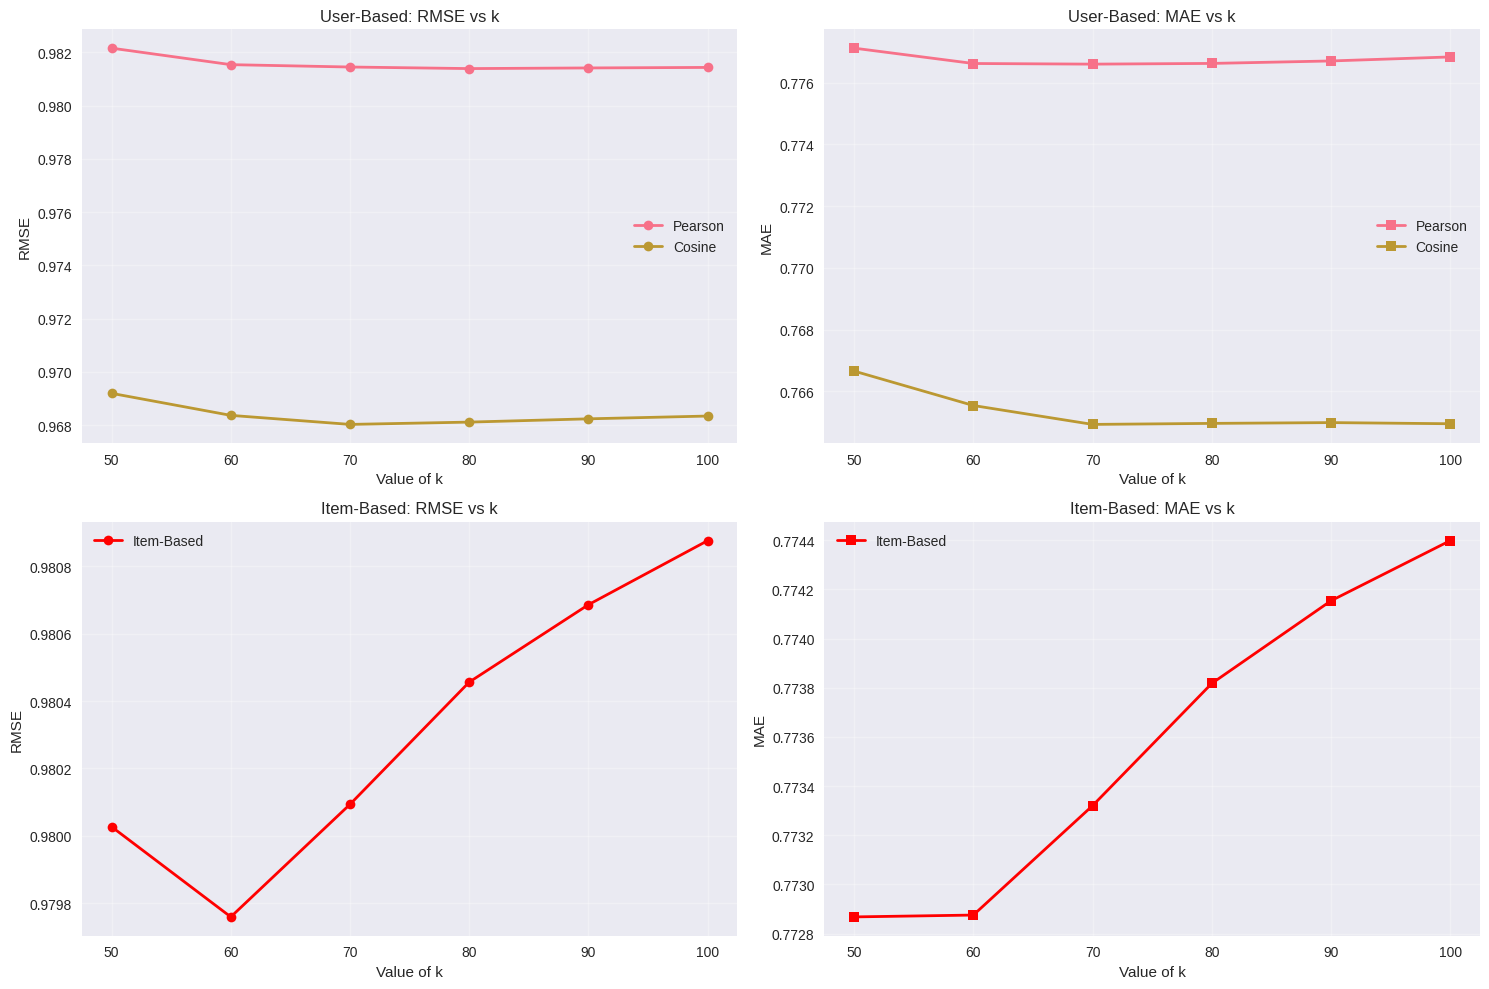

In [117]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def plot_k_performance_comparison(user_based_results, item_based_results, k_values):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # RMSE for User-Based
    for similarity in ['pearson', 'cosine']:
        rmse_values = [user_based_results[similarity][k]['RMSE'] for k in k_values]
        ax1.plot(k_values, rmse_values, marker='o', linewidth=2, label=f'{similarity.capitalize()}')
    
    ax1.set_xlabel('Value of k') 
    ax1.set_ylabel('RMSE') 
    ax1.set_title('User-Based: RMSE vs k')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # MAE for User-Based
    for similarity in ['pearson', 'cosine']:
        mae_values = [user_based_results[similarity][k]['MAE'] for k in k_values]
        ax2.plot(k_values, mae_values, marker='s', linewidth=2, label=f'{similarity.capitalize()}')
    
    ax2.set_xlabel('Value of k') 
    ax2.set_ylabel('MAE') 
    ax2.set_title('User-Based: MAE vs k')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # RMSE for Item-Based
    rmse_values_item = [item_based_results[k]['RMSE'] for k in k_values]
    ax3.plot(k_values, rmse_values_item, marker='o', linewidth=2, color='red', label='Item-Based')
    ax3.set_xlabel('Value of k') 
    ax3.set_ylabel('RMSE') 
    ax3.set_title('Item-Based: RMSE vs k')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # MAE for Item-Based
    mae_values_item = [item_based_results[k]['MAE'] for k in k_values]
    ax4.plot(k_values, mae_values_item, marker='s', linewidth=2, color='red', label='Item-Based')
    ax4.set_xlabel('Value of k') 
    ax4.set_ylabel('MAE') 
    ax4.set_title('Item-Based: MAE vs k')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_k_performance_comparison(user_based_results, item_based_results, k_values)